In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("aduhiyaiya.csv")
df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50154497,ELEMENTS PIZZERIA,Queens,83-01,NORTHERN BOULEVARD,11372.0,7187178753,Other,03/17/2025,Violations were cited in the following area(s).,02B,Hot TCS food item not held at or above 140 °F.,Critical,22.0,N,NaN,03/03/2026,Pre-permit (Operational) / Initial Inspection,40.755672,-73.884302,403.0,25.0,32700.0,4034565.0,4.014130e+09,QN28,POINT (-73.884301541496 40.755671854486)
1,50064466,LOCO COCO,Manhattan,835,LEXINGTON AVENUE,10065.0,9178156900,"Juice, Smoothies, Fruit Salads",06/22/2023,Violations were cited in the following area(s).,06E,"Sanitized equipment or utensil, including in-u...",Critical,12.0,A,06/22/2023,03/03/2026,Cycle Inspection / Initial Inspection,40.765142,-73.966041,108.0,4.0,12000.0,1042115.0,1.013980e+09,MN40,POINT (-73.966040729158 40.76514242275)
2,50158097,APU KENNEDY FRIED CHICKEN,Queens,127-07,MERRICK BOULEVARD,11434.0,3475458925,Chicken,03/17/2025,Violations were cited in the following area(s).,08A,Establishment is not free of harborage or cond...,Not Critical,44.0,Z,03/17/2025,03/03/2026,Pre-permit (Operational) / Re-inspection,40.681516,-73.765346,412.0,27.0,36600.0,4269971.0,4.124880e+09,QN08,POINT (-73.765345858131 40.681515758941)
3,50172767,FRESH BAKERY & SWEETS,Queens,37-15,73 STREET,11372.0,7182551445,Bakery Products/Desserts,01/09/2026,Violations were cited in the following area(s).,20-08,Failure to post or conspicuously post healthy ...,Not Critical,NaN,NaN,NaN,03/03/2026,Administrative Miscellaneous / Re-inspection,40.748426,-73.892622,403.0,25.0,28900.0,4518723.0,4.012848e+09,QN28,POINT (-73.892622308314 40.748425534989)
4,50181605,YOSHI NY INC.,Brooklyn,2,HAVEMEYER STREET,11211.0,6469610218,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.716484,-73.952783,301.0,33.0,51900.0,3061846.0,3.023140e+09,BK73,POINT (-73.95278333642 40.716484059461)


In [4]:
df.describe()

,CAMIS,ZIPCODE,SCORE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL
count,2.967660e+05,293576.000000,280188.000000,295339.000000,295339.000000,292176.000000,292203.000000,292203.000000,2.909300e+05,2.953390e+05
mean,4.806145e+07,10706.923161,25.161749,40.292099,-73.148456,254.923769,20.568711,29882.587995,2.586012e+06,2.478446e+09
std,3.755423e+06,616.227171,18.731612,4.192801,7.611227,130.374503,15.668773,31292.127581,1.356210e+06,1.338448e+09
min,3.007544e+07,6605.000000,0.000000,0.000000,-74.249101,101.000000,1.000000,100.000000,1.000000e+06,1.000000e+00
25%,5.000430e+07,10023.000000,12.000000,40.686661,-73.988620,106.000000,4.000000,8000.000000,1.051461e+06,1.011110e+09
50%,5.009207e+07,11101.000000,21.000000,40.732855,-73.955697,302.000000,20.000000,17300.000000,3.021633e+06,3.008020e+09
75%,5.012999e+07,11232.000000,33.000000,40.761237,-73.893827,402.000000,34.000000,42600.000000,4.011502e+06,4.006290e+09
max,5.018247e+07,69361.000000,203.000000,40.912822,0.000000,595.000000,51.000000,162100.000000,5.799501e+06,5.270001e+09


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 296766 entries, 0 to 296765
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296766 non-null  int64  
 1   DBA                    296764 non-null  str    
 2   BORO                   296766 non-null  str    
 3   BUILDING               295807 non-null  str    
 4   STREET                 296765 non-null  str    
 5   ZIPCODE                293576 non-null  float64
 6   PHONE                  296752 non-null  str    
 7   CUISINE DESCRIPTION    293485 non-null  str    
 8   INSPECTION DATE        296766 non-null  str    
 9   ACTION                 293485 non-null  str    
 10  VIOLATION CODE         291191 non-null  str    
 11  VIOLATION DESCRIPTION  291190 non-null  str    
 12  CRITICAL FLAG          296766 non-null  str    
 13  SCORE                  280188 non-null  float64
 14  GRADE                  146385 non-null  str    

## Early Preprocessing ##

## Ubah ke Inspection Level ##

In [6]:
for col in ["INSPECTION DATE", "GRADE DATE", "RECORD DATE"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

record_date = df["RECORD DATE"].dropna().max()
start_date = record_date - pd.DateOffset(years=3)

df_recent = df[
    (df["INSPECTION DATE"].notna()) &
    (df["INSPECTION DATE"] >= start_date) &
    (df["INSPECTION DATE"] <= record_date)
].copy()

df_recent["SCORE"] = pd.to_numeric(df_recent["SCORE"], errors="coerce")
df_recent["BORO"] = df_recent["BORO"].replace("0", "Unknown")
df_recent["VIOLATION CODE"] = df_recent["VIOLATION CODE"].astype("string").str.strip()
df_recent["CRITICAL FLAG"] = df_recent["CRITICAL FLAG"].astype("string").str.strip().str.lower()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

df_ins = (
    df_recent.groupby(inspection_key, as_index=False, dropna=False)
    .agg(
        DBA=("DBA", "first"),
        BORO=("BORO", "first"),
        BUILDING=("BUILDING", "first"),
        STREET=("STREET", "first"),
        ZIPCODE=("ZIPCODE", "first"),
        PHONE=("PHONE", "first"),
        CUISINE_DESCRIPTION=("CUISINE DESCRIPTION", "first"),
        ACTION=("ACTION", "first"),
        SCORE=("SCORE", "first"),
        GRADE=("GRADE", "first"),
        GRADE_DATE=("GRADE DATE", "first"),
        Latitude=("Latitude", "first"),
        Longitude=("Longitude", "first"),
        Community_Board=("Community Board", "first"),
        Council_District=("Council District", "first"),
        Census_Tract=("Census Tract", "first"),
        BIN=("BIN", "first"),
        BBL=("BBL", "first"),
        NTA=("NTA", "first"),
        violation_count=("VIOLATION CODE", lambda x: x.dropna().ne("").sum()),
        critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),
        has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any())
    )
)

df_ins.head()

,CAMIS,INSPECTION DATE,INSPECTION TYPE,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE_DESCRIPTION,ACTION,SCORE,GRADE,GRADE_DATE,Latitude,Longitude,Community_Board,Council_District,Census_Tract,BIN,BBL,NTA,violation_count,critical_count,has_critical
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,38.0,NaN,NaT,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,2,True
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,12.0,A,2023-08-22,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,10.0,A,2024-11-08,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,7.0,A,2026-02-27,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,2,1,True
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,D.J. REYNOLDS,Manhattan,351,WEST 57 STREET,10019.0,2122452912,Irish,Violations were cited in the following area(s).,10.0,A,2023-04-23,40.767326,-73.984310,104.0,3.0,13900.0,1026048.0,1.010480e+09,MN15,2,2,True


In [7]:
df_ins.info()

<class 'pandas.DataFrame'>
RangeIndex: 77629 entries, 0 to 77628
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CAMIS                77629 non-null  int64         
 1   INSPECTION DATE      77629 non-null  datetime64[us]
 2   INSPECTION TYPE      77629 non-null  str           
 3   DBA                  77629 non-null  str           
 4   BORO                 77629 non-null  str           
 5   BUILDING             77390 non-null  str           
 6   STREET               77629 non-null  str           
 7   ZIPCODE              76772 non-null  float64       
 8   PHONE                77626 non-null  str           
 9   CUISINE_DESCRIPTION  77629 non-null  str           
 10  ACTION               77629 non-null  str           
 11  SCORE                68860 non-null  float64       
 12  GRADE                46347 non-null  str           
 13  GRADE_DATE           44221 non-null  datet

In [8]:
df_ins.duplicated().sum()

np.int64(0)

In [9]:
df_ins.isna().sum()

CAMIS                      0
INSPECTION DATE            0
INSPECTION TYPE            0
DBA                        0
BORO                       0
BUILDING                 239
STREET                     0
ZIPCODE                  857
PHONE                      3
CUISINE_DESCRIPTION        0
ACTION                     0
SCORE                   8769
GRADE                  31282
GRADE_DATE             33408
Latitude                 386
Longitude                386
Community_Board         1234
Council_District        1230
Census_Tract            1230
BIN                     1604
BBL                      386
NTA                     1234
violation_count            0
critical_count             0
has_critical               0
dtype: int64

**Drop Missing Value in Score**

In [10]:
df_ins = df_ins.dropna(subset=["SCORE"]).copy()
df_ins['SCORE'].isna().sum()

np.int64(0)

**Penjelasan:** Drop baris yang SCORE-nya null karena SCORE adalah kolom target, tidak bisa diimputasi

In [11]:
df_ins.columns

Index(['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE', 'DBA', 'BORO',
       'BUILDING', 'STREET', 'ZIPCODE', 'PHONE', 'CUISINE_DESCRIPTION',
       'ACTION', 'SCORE', 'GRADE', 'GRADE_DATE', 'Latitude', 'Longitude',
       'Community_Board', 'Council_District', 'Census_Tract', 'BIN', 'BBL',
       'NTA', 'violation_count', 'critical_count', 'has_critical'],
      dtype='str')

## Ubah Tipe Data ##

In [12]:
for col in ["INSPECTION DATE", "GRADE_DATE"]:
    df_ins[col] = pd.to_datetime(df_ins[col], errors="coerce")

for col in ["SCORE", "Latitude", "Longitude"]:
    df_ins[col] = pd.to_numeric(df_ins[col], errors="coerce")

df_ins["ZIPCODE"] = df_ins["ZIPCODE"].astype("string").astype("category")

for col in ["BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]:
    df_ins[col] = df_ins[col].astype("category")
    
df_ins.dtypes

CAMIS                           int64
INSPECTION DATE        datetime64[us]
INSPECTION TYPE              category
DBA                               str
BORO                         category
BUILDING                          str
STREET                            str
ZIPCODE                      category
PHONE                             str
CUISINE_DESCRIPTION          category
ACTION                            str
SCORE                         float64
GRADE                             str
GRADE_DATE             datetime64[us]
Latitude                      float64
Longitude                     float64
Community_Board               float64
Council_District              float64
Census_Tract                  float64
BIN                           float64
BBL                           float64
NTA                               str
violation_count                 int64
critical_count                  int64
has_critical                     bool
dtype: object

**Penjelasan:** Yang Date itu krn tanggal jd pake datetime, yg score, latitude dan longitude itu bakal diproses secara numerik, selainnya itu krn emang kategorikal jadi diubah ke category aja

## Fitur inti ##

In [13]:
df_ins["inspection_year"] = df_ins["INSPECTION DATE"].dt.year
df_ins["inspection_month"] = df_ins["INSPECTION DATE"].dt.month
df_ins["inspection_quarter"] = df_ins["INSPECTION DATE"].dt.quarter
df_ins["inspection_dayofweek"] = df_ins["INSPECTION DATE"].dt.dayofweek

base_features = [
    "CUISINE_DESCRIPTION",
    "BORO",
    "ZIPCODE",
    "Latitude",
    "Longitude",
    "Community_Board",
    "INSPECTION TYPE",
    "inspection_year",
    "inspection_month",
    "inspection_quarter",
    "inspection_dayofweek"
]

df_base = df_ins[
    ["CAMIS", "INSPECTION DATE", "SCORE"] + base_features
].copy()

df_base.head()

,CAMIS,INSPECTION DATE,SCORE,CUISINE_DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,Community_Board,INSPECTION TYPE,inspection_year,inspection_month,inspection_quarter,inspection_dayofweek
0,30075445,2023-08-01,38.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2023,8,3,1
1,30075445,2023-08-22,12.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Re-inspection,2023,8,3,1
2,30075445,2024-11-08,10.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2024,11,4,4
3,30075445,2026-02-27,7.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2026,2,1,4
4,30191841,2023-04-23,10.0,Irish,Manhattan,10019.0,40.767326,-73.984310,104.0,Cycle Inspection / Initial Inspection,2023,4,2,6


In [14]:
df_base.columns

Index(['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'BORO',
       'ZIPCODE', 'Latitude', 'Longitude', 'Community_Board',
       'INSPECTION TYPE', 'inspection_year', 'inspection_month',
       'inspection_quarter', 'inspection_dayofweek'],
      dtype='str')

In [15]:
df_base.dtypes

CAMIS                            int64
INSPECTION DATE         datetime64[us]
SCORE                          float64
CUISINE_DESCRIPTION           category
BORO                          category
ZIPCODE                       category
Latitude                       float64
Longitude                      float64
Community_Board                float64
INSPECTION TYPE               category
inspection_year                  int32
inspection_month                 int32
inspection_quarter               int32
inspection_dayofweek             int32
dtype: object

## Handle Missing Value Boro, Zipcode, Cuisine Description, Inspection Type ##

In [16]:
cat_cols = ["BORO", "ZIPCODE", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]

for col in cat_cols:
    df_base[col] = df_base[col].replace(r"^\s*$", pd.NA, regex=True)

    if str(df_base[col].dtype) == "category":
        if "Unknown" not in df_base[col].cat.categories:
            df_base[col] = df_base[col].cat.add_categories(["Unknown"])

    df_base[col] = df_base[col].fillna("Unknown")
    
df_base[cat_cols].isna().sum()

BORO                   0
ZIPCODE                0
CUISINE_DESCRIPTION    0
INSPECTION TYPE        0
dtype: int64

In [17]:
df_base.info()

<class 'pandas.DataFrame'>
Index: 68860 entries, 0 to 77627
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CAMIS                 68860 non-null  int64         
 1   INSPECTION DATE       68860 non-null  datetime64[us]
 2   SCORE                 68860 non-null  float64       
 3   CUISINE_DESCRIPTION   68860 non-null  category      
 4   BORO                  68860 non-null  category      
 5   ZIPCODE               68860 non-null  category      
 6   Latitude              68505 non-null  float64       
 7   Longitude             68505 non-null  float64       
 8   Community_Board       67732 non-null  float64       
 9   INSPECTION TYPE       68860 non-null  category      
 10  inspection_year       68860 non-null  int32         
 11  inspection_month      68860 non-null  int32         
 12  inspection_quarter    68860 non-null  int32         
 13  inspection_dayofweek  68860 non-

## Handle Missing Value Community Board ##

In [18]:
df_base["Community_Board"] = df_base["Community_Board"].astype(str)
df_base["Community_Board"] = df_base["Community_Board"].replace(r"^\s*$", pd.NA, regex=True)
df_base["Community_Board"] = df_base["Community_Board"].fillna("Unknown")
df_base[["Community_Board"]].isna().sum()

Community_Board    0
dtype: int64

## Handle Missing Value Latitude Longitude ##

In [19]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     355
Longitude    355
dtype: int64

In [20]:
df_base["Latitude"] = pd.to_numeric(df_base["Latitude"], errors="coerce")
df_base["Longitude"] = pd.to_numeric(df_base["Longitude"], errors="coerce")

df_base.loc[df_base["Latitude"] == 0, "Latitude"] = pd.NA
df_base.loc[df_base["Longitude"] == 0, "Longitude"] = pd.NA

df_base["Latitude"] = df_base["Latitude"].fillna(
    df_base.groupby("CAMIS")["Latitude"].transform("median")
)

df_base["Longitude"] = df_base["Longitude"].fillna(
    df_base.groupby("CAMIS")["Longitude"].transform("median")
)

df_base["Latitude"] = df_base["Latitude"].fillna(df_base["Latitude"].median())
df_base["Longitude"] = df_base["Longitude"].fillna(df_base["Longitude"].median())

In [21]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     0
Longitude    0
dtype: int64

In [22]:
df_base.isna().sum()

CAMIS                   0
INSPECTION DATE         0
SCORE                   0
CUISINE_DESCRIPTION     0
BORO                    0
ZIPCODE                 0
Latitude                0
Longitude               0
Community_Board         0
INSPECTION TYPE         0
inspection_year         0
inspection_month        0
inspection_quarter      0
inspection_dayofweek    0
dtype: int64

## Top Category Cuisine & Inspection Type ##

In [23]:
TOP_N_CUISINE = 15
TOP_N_INSTYPE = 5

top_cuisine = df_base["CUISINE_DESCRIPTION"].value_counts().nlargest(TOP_N_CUISINE).index
df_base["CUISINE_DESCRIPTION"] = (
    df_base["CUISINE_DESCRIPTION"]
    .apply(lambda x: x if x in top_cuisine else "Other")
)

top_instype = df_base["INSPECTION TYPE"].value_counts().nlargest(TOP_N_INSTYPE).index
df_base["INSPECTION TYPE"] = (
    df_base["INSPECTION TYPE"]
    .apply(lambda x: x if x in top_instype else "Other")
)

In [24]:
print(df_base["CUISINE_DESCRIPTION"].value_counts())
print()
print(df_base["INSPECTION TYPE"].value_counts())
print(df_base["CUISINE_DESCRIPTION"].nunique())
print(df_base["INSPECTION TYPE"].nunique())

CUISINE_DESCRIPTION
Other                             18539
American                          11072
Chinese                            6221
Coffee/Tea                         5862
Pizza                              4184
Latin American                     2900
Bakery Products/Desserts           2778
Mexican                            2708
Japanese                           2364
Caribbean                          2259
Italian                            2191
Chicken                            1914
Donuts                             1701
Juice, Smoothies, Fruit Salads     1418
Spanish                            1414
Hamburgers                         1335
Name: count, dtype: int64

INSPECTION TYPE
Cycle Inspection / Initial Inspection            38133
Cycle Inspection / Re-inspection                 14453
Pre-permit (Operational) / Initial Inspection     9378
Other                                             3067
Pre-permit (Operational) / Re-inspection          2774
Cycle Inspection / Reo

**Penjelasan:** Cuisine diambil yang top 15 agar tidak terlalu banyak kategori karena diluar top 15 jumlahnya juga dikit, inspection type diambil yang top 5 aja dengan alasan yang sama selebihnya dikelompokkan sebagai Other

# Advance Preprocessing

### Feature Engineering dari Violations

In [25]:
inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

print("rows awal:", df_recent.shape[0])
print("unique inspeksi:",
      df_recent[inspection_key].drop_duplicates().shape[0])

rows awal: 243361
unique inspeksi: 77629


In [26]:
df_violation = df_recent.copy()
df_violation['CRITICAL FLAG'] = df_violation['CRITICAL FLAG'].str.strip().str.lower()
df_violation['VIOLATION CODE'] = df_violation['VIOLATION CODE'].str.strip()

df_violation = df_violation[
    df_violation["VIOLATION CODE"].notna() &
    (df_violation["VIOLATION CODE"] != "") &
    (df_violation["VIOLATION CODE"].str.lower() != "nan")
].copy()

df_violation = df_violation.drop_duplicates(
    subset=['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE', 'VIOLATION CODE']
).copy()

violation_agg = df_violation.groupby(
    ['CAMIS', 'INSPECTION DATE','INSPECTION TYPE']
).agg(
    critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),
    has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any()),
    noncritical_count=("CRITICAL FLAG", lambda x: (x != "critical").sum()),
    total_violation_count=('VIOLATION CODE', 'count'),
    unique_violation_codes=('VIOLATION CODE', 'nunique')
).reset_index()

violation_agg['has_critical'] = (violation_agg['critical_count'] > 0).astype(int)

violation_agg['critical_ratio'] = (
    violation_agg['critical_count'] / violation_agg['total_violation_count']
).fillna(0)

print("Jumlah duplikat:", violation_agg.duplicated().sum())
print("Shape:", violation_agg.shape)
violation_agg.head()

Jumlah duplikat: 0
Shape: (75607, 9)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,critical_count,has_critical,noncritical_count,total_violation_count,unique_violation_codes,critical_ratio
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,2,1,1,3,3,0.666667
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,1,1,2,3,3,0.333333
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,1,1,2,3,3,0.333333
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,1,1,1,2,2,0.500000
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,2,1,0,2,2,1.000000


In [27]:
top_codes = (
    df_violation['VIOLATION CODE']
    .astype(str)
    .str.strip()
    .value_counts()
    .head(10)
    .index
    .tolist()
)

for code in top_codes:
    df_violation[f'viol_{code}'] = (df_violation['VIOLATION CODE'] == code).astype(int)

flag_cols = [f'viol_{code}' for code in top_codes]

flag_agg = df_violation.groupby(
    ['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE']
)[flag_cols].max().reset_index()

print("Jumlah duplikat:", flag_agg.duplicated().sum())
print("Shape:", flag_agg.shape)

flag_agg.head()

Jumlah duplikat: 0
Shape: (75607, 13)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,viol_10F,viol_08A,viol_10B,viol_06C,viol_02G,viol_06D,viol_02B,viol_04L,viol_04N,viol_04A
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,0,1,0,0,0,0,0,1,0,0
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,0,1,0,0,0,0,0,1,0,0
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,1,0,0,1,0,0,0,0,0,0
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,1,0,0,0,0,0,0,0,0,0
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,0,0,0,1,0,0,0,0,0,0


In [28]:
violation_agg = violation_agg.merge(
    flag_agg,
    on=inspection_key,
    how='left'
)

violation_agg[flag_cols] = violation_agg[flag_cols].fillna(0)
print("Shape violation_agg:", violation_agg.shape)
violation_agg.head()

Shape violation_agg: (75607, 19)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,critical_count,has_critical,noncritical_count,total_violation_count,unique_violation_codes,critical_ratio,viol_10F,viol_08A,viol_10B,viol_06C,viol_02G,viol_06D,viol_02B,viol_04L,viol_04N,viol_04A
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,2,1,1,3,3,0.666667,0,1,0,0,0,0,0,1,0,0
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,1,1,2,3,3,0.333333,0,1,0,0,0,0,0,1,0,0
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,1,1,2,3,3,0.333333,1,0,0,1,0,0,0,0,0,0
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,1,1,1,2,2,0.500000,1,0,0,0,0,0,0,0,0,0
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,2,1,0,2,2,1.000000,0,0,0,1,0,0,0,0,0,0


In [29]:
df_base = df_base.merge(
    violation_agg,
    on=['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE'],
    how='left'
)

cols = [
    'critical_count',
    'noncritical_count',
    'total_violation_count',
    'unique_violation_codes',
    'has_critical',
    'critical_ratio'
] + flag_cols

df_base[cols] = df_base[cols].fillna(0)

print("Jumlah duplikat:", df_base.duplicated(inspection_key).sum())
print("Shape df_base:", df_base.shape)
df_base.columns.tolist()


Jumlah duplikat: 0
Shape df_base: (68860, 30)


['CAMIS',
 'INSPECTION DATE',
 'SCORE',
 'CUISINE_DESCRIPTION',
 'BORO',
 'ZIPCODE',
 'Latitude',
 'Longitude',
 'Community_Board',
 'INSPECTION TYPE',
 'inspection_year',
 'inspection_month',
 'inspection_quarter',
 'inspection_dayofweek',
 'critical_count',
 'has_critical',
 'noncritical_count',
 'total_violation_count',
 'unique_violation_codes',
 'critical_ratio',
 'viol_10F',
 'viol_08A',
 'viol_10B',
 'viol_06C',
 'viol_02G',
 'viol_06D',
 'viol_02B',
 'viol_04L',
 'viol_04N',
 'viol_04A']

In [30]:
print("=== Info df_base ===")
print(df_base[cols].describe())
print()
print("=== Missing values fitur violation ===")
print(df_base[cols].isna().sum())
print()
print("=== Contoh data ===")
df_base[[
    "CAMIS", "INSPECTION DATE", "SCORE",
    "total_violation_count", "critical_count", "noncritical_count",
    "unique_violation_codes", "critical_ratio", "has_critical"
]].head(10)

=== Info df_base ===
       critical_count  noncritical_count  total_violation_count  \
count    68860.000000       68860.000000           68860.000000   
mean         1.815800           1.423352               3.239152   
std          1.526577           1.073900               2.121978   
min          0.000000           0.000000               0.000000   
25%          1.000000           1.000000               2.000000   
50%          1.000000           1.000000               3.000000   
75%          3.000000           2.000000               4.000000   
max         13.000000           8.000000              19.000000   

       unique_violation_codes  has_critical  critical_ratio      viol_10F  \
count            68860.000000   68860.00000    68860.000000  68860.000000   
mean                 3.239152       0.84226        0.510210      0.482515   
std                  2.121978       0.36450        0.301085      0.499698   
min                  0.000000       0.00000        0.000000      0.

,CAMIS,INSPECTION DATE,SCORE,total_violation_count,critical_count,noncritical_count,unique_violation_codes,critical_ratio,has_critical
0,30075445,2023-08-01,38.0,3.0,2.0,1.0,3.0,0.666667,1.0
1,30075445,2023-08-22,12.0,3.0,1.0,2.0,3.0,0.333333,1.0
2,30075445,2024-11-08,10.0,3.0,1.0,2.0,3.0,0.333333,1.0
3,30075445,2026-02-27,7.0,2.0,1.0,1.0,2.0,0.500000,1.0
4,30191841,2023-04-23,10.0,2.0,2.0,0.0,2.0,1.000000,1.0
5,30191841,2024-11-20,24.0,6.0,2.0,4.0,6.0,0.333333,1.0
6,30191841,2025-02-20,10.0,2.0,2.0,0.0,2.0,1.000000,1.0
7,40356018,2024-04-16,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
8,40356018,2025-09-17,10.0,2.0,1.0,1.0,2.0,0.500000,1.0
9,40356483,2023-11-16,35.0,6.0,3.0,3.0,6.0,0.500000,1.0


### Features Engineering Historis per Restoran


In [31]:
df_past = df_base.copy()
df_past['INSPECTION DATE'] = pd.to_datetime(df_past['INSPECTION DATE'])

df_past = df_past.sort_values(['CAMIS', 'INSPECTION DATE'])

df_past['prev_score'] = df_past.groupby('CAMIS')['SCORE'].shift(1)

df_past['avg_score_last_3'] = (
    df_past.groupby('CAMIS')['SCORE']
    .rolling(3)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

df_past['repeat_critical_flag'] = (
    df_past.groupby('CAMIS')['has_critical']
    .cummax()
    .shift(1)
)

df_past['days_since_last_inspection'] = (
    df_past.groupby('CAMIS')['INSPECTION DATE']
    .diff()
    .dt.days
)

hist_cols = ["prev_score", "avg_score_last_3",
             "days_since_last_inspection", "repeat_critical_flag"]

print("Shape of df_past[hist_cols]:", df_past.shape)
df_past[hist_cols].isna().sum()


Shape of df_past[hist_cols]: (68860, 34)


prev_score                    27071
avg_score_last_3              48696
days_since_last_inspection    27071
repeat_critical_flag              1
dtype: int64

In [32]:
df_past['prev_score'] = np.log1p(df_past['prev_score']) 
df_past['avg_score_last_3'] = np.log1p(df_past['avg_score_last_3'])

median_vals = df_past['SCORE'].median()

df_past['prev_score'] = df_past['prev_score'].fillna(median_vals)
df_past['avg_score_last_3'] = df_past['avg_score_last_3'].fillna(median_vals)
df_past['days_since_last_inspection'] = df_past['days_since_last_inspection'].fillna(-1)
df_past['repeat_critical_flag'] = df_past['repeat_critical_flag'].fillna(0)

df_past[hist_cols].isna().sum()


prev_score                    0
avg_score_last_3              0
days_since_last_inspection    0
repeat_critical_flag          0
dtype: int64

In [33]:
df_base = df_past.copy()

print("=== Distribusi fitur historis ===")
df_base[hist_cols].describe()

=== Distribusi fitur historis ===


,prev_score,avg_score_last_3,days_since_last_inspection,repeat_critical_flag
count,68860.000000,68860.000000,68860.000000,68860.000000
mean,6.813723,10.065413,180.077215,0.926823
std,5.020827,4.569025,216.874775,0.260429
min,0.000000,0.000000,-1.000000,0.000000
25%,2.639057,3.486355,-1.000000,1.000000
50%,3.555348,13.000000,63.000000,1.000000
75%,13.000000,13.000000,367.000000,1.000000
max,13.000000,13.000000,1078.000000,1.000000


### Features Engineering Geospasial

In [34]:
df_geo = df_base.copy()
df_geo = df_geo.sort_values(['INSPECTION DATE'])

boro_group = df_geo.groupby('BORO')['SCORE']

df_geo['boro_mean_score'] = (
    boro_group.expanding().mean().shift(1)
    .reset_index(level=0, drop=True)
)

df_geo['boro_median_score'] = (
    boro_group.expanding().median().shift(1)
    .reset_index(level=0, drop=True)
)

zip_group = df_geo.groupby('ZIPCODE')['SCORE']

df_geo['zipcode_mean_score'] = (
    zip_group.expanding().mean().shift(1)
    .reset_index(level=0, drop=True)
)

df_geo['zipcode_median_score'] = (
    zip_group.expanding().median().shift(1)
    .reset_index(level=0, drop=True)
)

cb_group = df_geo.groupby('Community_Board')['SCORE']

df_geo['community_board_mean_score'] = (
    cb_group.expanding().mean().shift(1)
    .reset_index(level=0, drop=True)
)

df_geo['community_board_median_score'] = (
    cb_group.expanding().median().shift(1)
    .reset_index(level=0, drop=True)
)

geo_cols = [
    'boro_mean_score', 'boro_median_score',
    'zipcode_mean_score', 'zipcode_median_score',
    'community_board_mean_score', 'community_board_median_score'
]

df_geo[geo_cols] = df_geo[geo_cols].fillna(median_vals)

df_base = df_geo.copy()
print(df_base[geo_cols].isna().sum())
df_base[['BORO','SCORE','boro_mean_score','boro_median_score']].head(10)


boro_mean_score                 0
boro_median_score               0
zipcode_mean_score              0
zipcode_median_score            0
community_board_mean_score      0
community_board_median_score    0
dtype: int64


,BORO,SCORE,boro_mean_score,boro_median_score
28286,Queens,13.0,17.384430,12.0
44139,Brooklyn,12.0,17.723636,13.0
4697,Manhattan,2.0,18.158726,13.0
28080,Manhattan,2.0,2.000000,2.0
40124,Queens,4.0,13.000000,13.0
34236,Manhattan,2.0,2.000000,2.0
46153,Brooklyn,32.0,12.000000,12.0
9662,Brooklyn,0.0,22.000000,22.0
1934,Brooklyn,19.0,14.666667,12.0
36402,Queens,13.0,8.500000,8.5


### Analisis Korelasi dan Seleksi Fitur

In [35]:
num_cols = [
    c for c in df_base.select_dtypes(include="number").columns
    if c != 'SCORE'
]

pearson_corr = df_base[num_cols + ['SCORE']].corr(method='pearson')
spearman_corr = df_base[num_cols + ['SCORE']].corr(method='spearman')

pearson_corr['SCORE'].sort_values(ascending=False)


SCORE                           1.000000
critical_count                  0.810562
unique_violation_codes          0.783740
total_violation_count           0.783740
viol_08A                        0.421128
noncritical_count               0.396400
viol_02G                        0.350733
has_critical                    0.306254
critical_ratio                  0.295450
viol_02B                        0.291820
viol_04L                        0.286172
viol_04A                        0.277126
viol_06C                        0.274948
viol_04N                        0.257191
viol_06D                        0.165775
viol_10B                        0.139647
zipcode_mean_score              0.097100
community_board_mean_score      0.089625
CAMIS                           0.075573
zipcode_median_score            0.068341
boro_mean_score                 0.067482
prev_score                      0.067026
community_board_median_score    0.063958
Longitude                       0.049577
boro_median_scor

In [36]:
spearman_corr['SCORE'].sort_values(ascending=False)

SCORE                           1.000000
critical_count                  0.838134
unique_violation_codes          0.818714
total_violation_count           0.818714
has_critical                    0.492786
viol_08A                        0.479486
critical_ratio                  0.424466
viol_02G                        0.380793
noncritical_count               0.375615
viol_04L                        0.328939
viol_02B                        0.320815
viol_04N                        0.280551
viol_04A                        0.278374
viol_06C                        0.273971
viol_06D                        0.181854
viol_10B                        0.141879
CAMIS                           0.101320
zipcode_mean_score              0.098870
community_board_mean_score      0.096695
prev_score                      0.092943
zipcode_median_score            0.091820
community_board_median_score    0.091494
repeat_critical_flag            0.066068
boro_mean_score                 0.062638
Longitude       

In [37]:
df_corr_rank = (
    spearman_corr['SCORE']
    .drop('SCORE')
    .sort_values(key=lambda x: abs(x), ascending=False)
    .reset_index()
)

df_corr_rank.columns = ['feature', 'spearman_corr']
df_corr_rank

,feature,spearman_corr
0,critical_count,0.838134
1,unique_violation_codes,0.818714
2,total_violation_count,0.818714
3,has_critical,0.492786
4,viol_08A,0.479486
5,critical_ratio,0.424466
6,viol_02G,0.380793
7,noncritical_count,0.375615
8,viol_04L,0.328939
9,viol_02B,0.320815


In [38]:
high_corr = np.where(np.abs(spearman_corr) > 0.9)

pairs = [
    (spearman_corr.index[x], spearman_corr.columns[y])
    for x, y in zip(*high_corr)
    if x != y and x < y
]

pairs

[('inspection_month', 'inspection_quarter'),
 ('total_violation_count', 'unique_violation_codes'),
 ('prev_score', 'days_since_last_inspection')]

In [39]:
from scipy import stats
cat_cols_to_check = [
    "BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE", "ZIPCODE", "Community_Board"
]

eta_results = []
for col in cat_cols_to_check:
    tmp = df_base[[col, "SCORE"]].dropna().copy()
    tmp[col] = tmp[col].astype(str)

    groups = [grp["SCORE"].values for _, grp in tmp.groupby(col) if len(grp) >= 5]
    if len(groups) < 2:
        continue

    f_stat, p_val = stats.f_oneway(*groups)

    grand_mean = tmp["SCORE"].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = sum((tmp["SCORE"] - grand_mean)**2)
    eta_sq     = ss_between / ss_total if ss_total > 0 else 0

    eta_results.append({
        "feature":    col,
        "f_stat":     round(f_stat, 4),
        "p_value":    round(p_val, 6),
        "eta_squared": round(eta_sq, 6),
        "n_categories": tmp[col].nunique(),
    })

df_eta = (
    pd.DataFrame(eta_results)
    .sort_values("eta_squared", ascending=False)
    .reset_index(drop=True)
)

ETA_THRESHOLD = 0.01
df_eta["keep"] = df_eta["eta_squared"] >= ETA_THRESHOLD
df_eta["effect_size"] = df_eta["eta_squared"].apply(
    lambda x: "Large (η²≥0.14)" if x >= 0.14
    else "Medium (η²≥0.06)" if x >= 0.06
    else "Small (η²≥0.01)" if x >= 0.01
    else "Negligible"
)

print(f"Total fitur kategorikal diperiksa: {len(df_eta)}")
print()
df_eta

Total fitur kategorikal diperiksa: 5



,feature,f_stat,p_value,eta_squared,n_categories,keep,effect_size
0,CUISINE_DESCRIPTION,112.4816,0.0,0.023922,16,True,Small (η²≥0.01)
1,INSPECTION TYPE,288.1229,0.0,0.020494,6,True,Small (η²≥0.01)
2,ZIPCODE,6.5192,0.0,0.018733,230,True,Small (η²≥0.01)
3,Community_Board,11.8809,0.0,0.011102,70,True,Small (η²≥0.01)
4,BORO,45.3612,0.0,0.003283,6,False,Negligible


Drop inspection_quarter dulu aja

In [40]:
df_base = df_base.drop(columns=['inspection_quarter'])

### Encoding Fitur Kategorikal

In [ ]:
ohe_cols = ["INSPECTION TYPE"]

df_encoded = pd.get_dummies(
    df_base,
    columns=ohe_cols,
    prefix={"INSPECTION TYPE": "instype"},
    drop_first=False,   
    dtype=int           
)

print(f"Shape sebelum OHE: {df_base.shape}")
print(f"Shape setelah OHE: {df_encoded.shape}")
print(f"Kolom baru dari OHE ({df_encoded.shape[1] - df_base.shape[1]}):")
new_ohe_cols = [c for c in df_encoded.columns if c.startswith("cuisine_") or c.startswith("instype_")]
print(new_ohe_cols)

Shape sebelum OHE: (68860, 39)
Shape setelah OHE: (68860, 44)
Kolom baru dari OHE (5):
['instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-inspection']


In [ ]:
raw_cat_to_drop = ["ZIPCODE", "Community_Board", "CUISINE_DESCRIPTION", "BORO"]
id_cols         = ["CAMIS", "INSPECTION DATE"]

df_ids = df_encoded[id_cols].copy()

df_encoded = df_encoded.drop(
    columns=[c for c in raw_cat_to_drop + id_cols if c in df_encoded.columns]
)

print(f"Shape df_encoded setelah drop kolom raw: {df_encoded.shape}")
print()
print("Kolom final df_encoded:")
print(df_encoded.columns.tolist())

Shape df_encoded setelah drop kolom raw: (68860, 38)

Kolom final df_encoded:
['SCORE', 'Latitude', 'Longitude', 'inspection_year', 'inspection_month', 'inspection_dayofweek', 'critical_count', 'has_critical', 'noncritical_count', 'total_violation_count', 'unique_violation_codes', 'critical_ratio', 'viol_10F', 'viol_08A', 'viol_10B', 'viol_06C', 'viol_02G', 'viol_06D', 'viol_02B', 'viol_04L', 'viol_04N', 'viol_04A', 'prev_score', 'avg_score_last_3', 'repeat_critical_flag', 'days_since_last_inspection', 'boro_mean_score', 'boro_median_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-inspection']


In [ ]:
df_encoded["has_critical"] = df_encoded["has_critical"].astype(int)

non_numeric = df_encoded.select_dtypes(exclude="number").columns.tolist()

if non_numeric:
    print(f"Masih ada kolom non-numerik: {non_numeric}")
    print("Perlu ditangani sebelum modeling!")
else:
    print("Semua kolom sudah numerik — df_encoded siap untuk tahap scaling & modeling")

print(f"\nShape final: {df_encoded.shape}")
print(f"Missing values total: {df_encoded.isna().sum().sum()}")
print()
print("=== Dtypes summary ===")
print(df_encoded.dtypes.value_counts())
print()
print("=== Preview 5 baris pertama ===")
df_encoded.head()

Semua kolom sudah numerik — df_encoded siap untuk tahap scaling & modeling

Shape final: (68860, 38)
Missing values total: 0

=== Dtypes summary ===
float64    28
int64       7
int32       3
Name: count, dtype: int64

=== Preview 5 baris pertama ===


,SCORE,Latitude,Longitude,inspection_year,inspection_month,inspection_dayofweek,critical_count,has_critical,noncritical_count,total_violation_count,unique_violation_codes,critical_ratio,viol_10F,viol_08A,viol_10B,viol_06C,viol_02G,viol_06D,viol_02B,viol_04L,viol_04N,viol_04A,prev_score,avg_score_last_3,repeat_critical_flag,days_since_last_inspection,boro_mean_score,boro_median_score,zipcode_mean_score,zipcode_median_score,community_board_mean_score,community_board_median_score,instype_Cycle Inspection / Initial Inspection,instype_Cycle Inspection / Re-inspection,instype_Cycle Inspection / Reopening Inspection,instype_Other,instype_Pre-permit (Operational) / Initial Inspection,instype_Pre-permit (Operational) / Re-inspection
28286,13.0,40.720432,-73.844604,2023,3,4,1.0,1,1.0,2.0,2.0,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,13.0,2.397895,1.0,-1.0,17.384430,12.0,18.018182,13.0,17.594313,13.0,1,0,0,0,0,0
44139,12.0,40.710758,-73.951096,2023,3,4,1.0,1,2.0,3.0,3.0,0.333333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.0,2.662588,1.0,-1.0,17.723636,13.0,19.514851,12.0,9.600000,12.0,0,1,0,0,0,0
4697,2.0,40.728942,-73.978370,2023,3,4,0.0,0,1.0,1.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,13.000000,1.0,-1.0,18.158726,13.0,16.345588,12.0,17.113572,12.0,1,0,0,0,0,0
28080,2.0,40.725658,-73.988206,2023,3,4,0.0,0,1.0,1.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,13.000000,1.0,-1.0,2.000000,2.0,18.298113,13.0,2.000000,2.0,1,0,0,0,0,0
40124,4.0,40.709782,-73.846616,2023,3,4,0.0,0,2.0,2.0,2.0,0.000000,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,13.000000,1.0,-1.0,13.000000,13.0,13.000000,13.0,13.000000,13.0,0,0,0,0,1,0


In [ ]:
from scipy.stats.mstats import winsorize

cols_to_winsorize = [
    "total_violation_count", "critical_count", "noncritical_count",
    "unique_violation_codes", "critical_ratio"
]

for col in cols_to_winsorize:
    upper = df_encoded[col].quantile(0.99)
    df_encoded[col] = df_encoded[col].clip(upper=upper)
    print(f"{col:<25} capped at P99 = {upper:.2f}")

print("\nWinsorize fitur numerik selesai")

total_violation_count     capped at P99 = 10.00
critical_count            capped at P99 = 7.00
noncritical_count         capped at P99 = 4.00
unique_violation_codes    capped at P99 = 10.00
critical_ratio            capped at P99 = 1.00

Winsorize fitur numerik selesai


In [ ]:
skew_df = (
    df_encoded[[c for c in df_encoded.columns
                if not any(c.startswith(p) for p in 
                          ["cuisine_", "instype_", "viol_"])
                and c not in ["has_critical", "SCORE"]]]
    .skew()
    .abs()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", 0: "abs_skewness"})
)

skew_df["perlu_log"] = skew_df["abs_skewness"] > 1.0  

print(skew_df.to_string(index=False))

                     feature  abs_skewness  perlu_log
        zipcode_median_score      6.455681       True
community_board_median_score      6.093655       True
        repeat_critical_flag      3.277931       True
          zipcode_mean_score      1.381656       True
           boro_median_score      1.312058       True
              critical_count      1.120576       True
             boro_mean_score      1.051210       True
       total_violation_count      1.007890       True
      unique_violation_codes      1.007890       True
            avg_score_last_3      0.923317      False
  days_since_last_inspection      0.875728      False
           noncritical_count      0.536622      False
  community_board_mean_score      0.434554      False
                  prev_score      0.384908      False
        inspection_dayofweek      0.243358      False
                   Longitude      0.206318      False
              critical_ratio      0.129107      False
                    Latitude

In [ ]:
for col in ["critical_count", "total_violation_count", "unique_violation_codes"]:
    df_encoded[col] = np.log1p(df_encoded[col])
    print(f"{col} → log1p applied")

critical_count → log1p applied
total_violation_count → log1p applied
unique_violation_codes → log1p applied


Total fitur masuk modeling: 37
Fitur dengan |ρ| ≥ 0.05: 27
Fitur dengan |ρ| < 0.05: 10



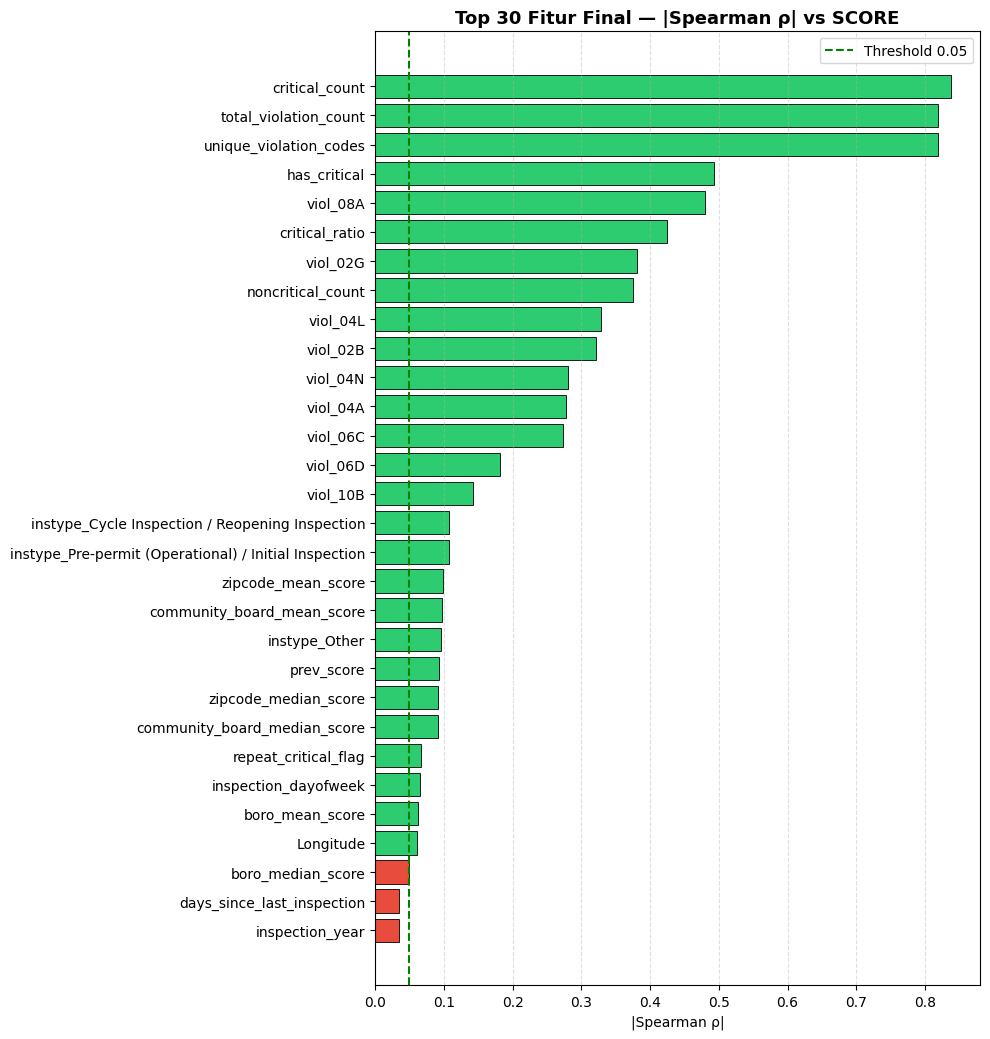


=== Top 10 fitur paling prediktif ===
               feature  abs_spearman_rho
        critical_count          0.838132
 total_violation_count          0.818710
unique_violation_codes          0.818710
          has_critical          0.492786
              viol_08A          0.479486
        critical_ratio          0.424466
              viol_02G          0.380793
     noncritical_count          0.375468
              viol_04L          0.328939
              viol_02B          0.320815


In [ ]:
final_corr = (
    df_encoded.corr(method="spearman")["SCORE"]
    .drop("SCORE")
    .abs()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", "SCORE": "abs_spearman_rho"})
)

print(f"Total fitur masuk modeling: {len(final_corr)}")
print(f"Fitur dengan |ρ| ≥ 0.05: {(final_corr['abs_spearman_rho'] >= 0.05).sum()}")
print(f"Fitur dengan |ρ| < 0.05: {(final_corr['abs_spearman_rho'] < 0.05).sum()}")
print()

top_n = min(30, len(final_corr))
plot_df = final_corr.head(top_n)

fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.35)))
colors = ["#2ecc71" if v >= 0.05 else "#e74c3c" for v in plot_df["abs_spearman_rho"]]
ax.barh(plot_df["feature"], plot_df["abs_spearman_rho"],
        color=colors, edgecolor="black", linewidth=0.6)
ax.axvline(0.05, color="green", linestyle="--", linewidth=1.5, label="Threshold 0.05")
ax.set_title(f"Top {top_n} Fitur Final — |Spearman ρ| vs SCORE", fontsize=13, fontweight="bold")
ax.set_xlabel("|Spearman ρ|")
ax.legend()
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== Top 10 fitur paling prediktif ===")
print(final_corr.head(10).to_string(index=False))

### Handling Outlier

=== Statistik SCORE (sebelum handling) ===
Min    : 0.0
Q1     : 9.0
Median : 13.0
Mean   : 18.12
Q3     : 24.0
P95    : 47.0
P99    : 73.0
Max    : 203.0
Skewness: 2.209

Outlier (IQR): 3,628 baris (5.3%)
Outlier ekstrem (>P99=73.0): 654 baris


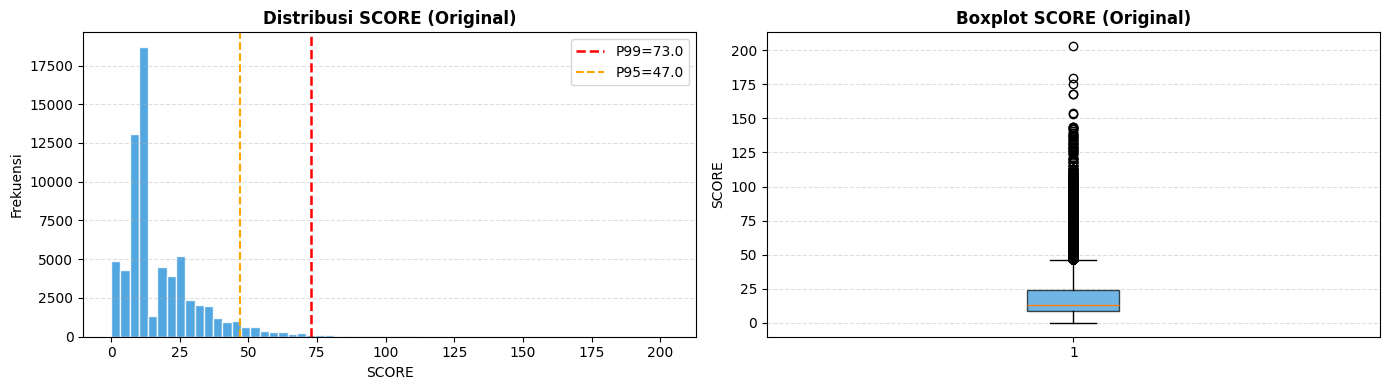

In [ ]:
score = df_encoded["SCORE"]

q1  = score.quantile(0.25)
q3  = score.quantile(0.75)
iqr = q3 - q1
p99 = score.quantile(0.99)
p95 = score.quantile(0.95)

print("=== Statistik SCORE (sebelum handling) ===")
print(f"Min    : {score.min():.1f}")
print(f"Q1     : {q1:.1f}")
print(f"Median : {score.median():.1f}")
print(f"Mean   : {score.mean():.2f}")
print(f"Q3     : {q3:.1f}")
print(f"P95    : {p95:.1f}")
print(f"P99    : {p99:.1f}")
print(f"Max    : {score.max():.1f}")
print(f"Skewness: {score.skew():.3f}")
print(f"\nOutlier (IQR): {(score > q3 + 1.5*iqr).sum():,} baris ({(score > q3 + 1.5*iqr).mean()*100:.1f}%)")
print(f"Outlier ekstrem (>P99={p99:.1f}): {(score > p99).sum():,} baris")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(score, bins=60, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(p99, color="red",    linestyle="--", linewidth=1.8, label=f"P99={p99:.1f}")
axes[0].axvline(p95, color="orange", linestyle="--", linewidth=1.5, label=f"P95={p95:.1f}")
axes[0].set_title("Distribusi SCORE (Original)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("SCORE"); axes[0].set_ylabel("Frekuensi")
axes[0].legend(); axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].boxplot(score, vert=True, patch_artist=True, boxprops=dict(facecolor="#3498db", alpha=0.7))
axes[1].set_title("Boxplot SCORE (Original)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("SCORE"); axes[1].grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
CAP_PERCENTILE = 0.99
score_cap = df_encoded["SCORE"].quantile(CAP_PERCENTILE)
df_encoded["SCORE"] = df_encoded["SCORE"].clip(upper=score_cap)

print(f"[Winsorize] Cap di P99 = {score_cap:.1f}")
print(f"Baris yang di-cap: {(df_encoded['SCORE'] == score_cap).sum():,}")
print(f"Skewness setelah winsorize: {df_encoded['SCORE'].skew():.3f}")
print()


df_encoded["SCORE"] = np.log1p(df_encoded["SCORE"])

print(f"[Log1p] Transform diterapkan: SCORE = log(SCORE_winsorized + 1)")
print(f"Skewness setelah log1p      : {df_encoded['SCORE'].skew():.3f}")
print(f"Range SCORE sekarang        : [{df_encoded['SCORE'].min():.3f}, {df_encoded['SCORE'].max():.3f}]")
print()

[Winsorize] Cap di P99 = 73.0
Baris yang di-cap: 700
Skewness setelah winsorize: 1.621

[Log1p] Transform diterapkan: SCORE = log(SCORE_winsorized + 1)
Skewness setelah log1p      : -0.714
Range SCORE sekarang        : [0.000, 4.304]



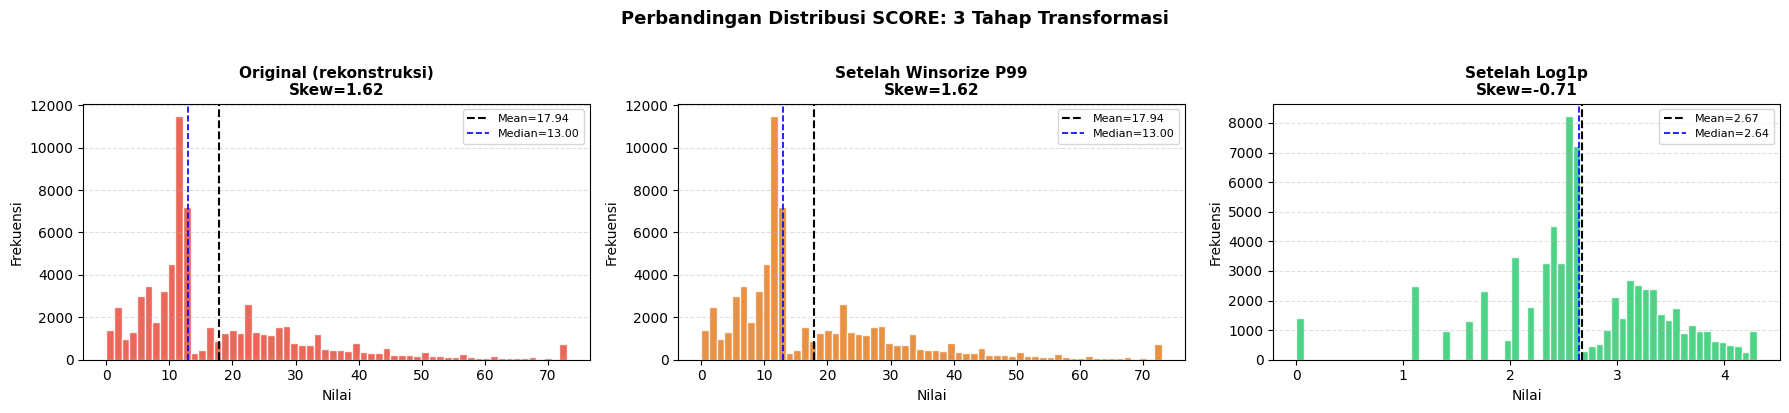

In [ ]:
score_original  = df_encoded["SCORE"].apply(np.expm1).clip(upper=score_cap)  
score_winsorize = score_original 
score_log1p     = df_encoded["SCORE"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

data_stages = [
    (df_encoded["SCORE"].apply(np.expm1), "Original (rekonstruksi)", "#e74c3c"),
    (score_winsorize,                      f"Setelah Winsorize P99",   "#e67e22"),
    (score_log1p,                          "Setelah Log1p",            "#2ecc71"),
]

for ax, (data, title, color) in zip(axes, data_stages):
    ax.hist(data, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="black",  linestyle="--", linewidth=1.5,
               label=f"Mean={data.mean():.2f}")
    ax.axvline(data.median(), color="blue",   linestyle="--", linewidth=1.2,
               label=f"Median={data.median():.2f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Nilai"); ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_title(f"{title}\nSkew={data.skew():.2f}", fontsize=11, fontweight="bold")

plt.suptitle("Perbandingan Distribusi SCORE: 3 Tahap Transformasi",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Train-Test Split

In [ ]:
df_split = df_encoded.copy()
df_split["INSPECTION DATE"] = pd.to_datetime(df_ids["INSPECTION DATE"].values)
df_split["CAMIS"]           = df_ids["CAMIS"].values
df_split = df_split.sort_values("INSPECTION DATE").reset_index(drop=True)

n = len(df_split)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_split.iloc[:train_end].copy()
val_df   = df_split.iloc[train_end:val_end].copy()
test_df  = df_split.iloc[val_end:].copy()

print(f"Total data       : {n:,}")
print(f"\nTrain  : {len(train_df):,} baris ({len(train_df)/n*100:.1f}%)")
print(f"  Periode: {train_df['INSPECTION DATE'].min().date()} → {train_df['INSPECTION DATE'].max().date()}")
print(f"\nVal    : {len(val_df):,} baris ({len(val_df)/n*100:.1f}%)")
print(f"  Periode: {val_df['INSPECTION DATE'].min().date()} → {val_df['INSPECTION DATE'].max().date()}")
print(f"\nTest   : {len(test_df):,} baris ({len(test_df)/n*100:.1f}%)")
print(f"  Periode: {test_df['INSPECTION DATE'].min().date()} → {test_df['INSPECTION DATE'].max().date()}")

Total data       : 68,860

Train  : 48,202 baris (70.0%)
  Periode: 2023-03-03 → 2025-05-09

Val    : 10,329 baris (15.0%)
  Periode: 2025-05-09 → 2025-10-07

Test   : 10,329 baris (15.0%)
  Periode: 2025-10-07 → 2026-02-28


In [ ]:
te_map = {
    "zipcode_mean_score":            ("ZIPCODE",         "mean"),
    "zipcode_median_score":          ("ZIPCODE",         "median"),
    "boro_mean_score":               ("BORO",            "mean"),
    "community_board_median_score":  ("Community_Board", "median"),
}

camis_geo = (
    df_ins[["CAMIS", "ZIPCODE", "BORO", "Community_Board"]]
    .copy()
    .astype(str)
    .replace("nan", pd.NA)        
    .dropna(subset=["CAMIS"])     
    .groupby("CAMIS", as_index=False)
    .first()                    
)

for df_ in [train_df, val_df, test_df]:
    df_["CAMIS"] = df_["CAMIS"].astype(str)

for geo_col in ["ZIPCODE", "BORO", "Community_Board"]:
    camis_to_geo = camis_geo.set_index("CAMIS")[geo_col]
    for df_ in [train_df, val_df, test_df]:
        df_[geo_col] = df_["CAMIS"].map(camis_to_geo)

global_median_train = train_df["SCORE"].median()

for new_col, (geo_col, agg_fn) in te_map.items():
    if new_col not in train_df.columns:
        continue
    stats_dict = (
        train_df.dropna(subset=[geo_col])
        .groupby(geo_col)["SCORE"]
        .agg(agg_fn)
        .to_dict()
    )
    for df_ in [train_df, val_df, test_df]:
        df_[new_col] = df_[geo_col].map(stats_dict).fillna(global_median_train)

geo_temp_cols = ["ZIPCODE", "BORO", "Community_Board"]
for df_ in [train_df, val_df, test_df]:
    df_.drop(columns=geo_temp_cols, errors="ignore", inplace=True)

print("\u2705 Target encoding di-refit dari train set saja, applied ke val & test")
print(f"\nTrain: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")

✅ Target encoding di-refit dari train set saja, applied ke val & test

Train: (48202, 40) | Val: (10329, 40) | Test: (10329, 40)


In [ ]:
drop_final = ["INSPECTION DATE", "CAMIS"]

X_train = train_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_train = train_df["SCORE"]

X_val   = val_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_val   = val_df["SCORE"]

X_test  = test_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_test  = test_df["SCORE"]

print("=" * 55)
print("  HASIL AKHIR PREPROCESSING")
print("=" * 55)
print(f"X_train : {X_train.shape}  | y mean={y_train.mean():.3f}, std={y_train.std():.3f}")
print(f"X_val   : {X_val.shape}   | y mean={y_val.mean():.3f}, std={y_val.std():.3f}")
print(f"X_test  : {X_test.shape}   | y mean={y_test.mean():.3f}, std={y_test.std():.3f}")
print(f"\nJumlah fitur masuk modeling: {X_train.shape[1]}")
print(f"\ny dalam skala log1p — pakai np.expm1(y_pred) saat evaluasi ke skala asli")
print(f"\nFeature list:")
print(X_train.columns.tolist())

  HASIL AKHIR PREPROCESSING
X_train : (48202, 37)  | y mean=2.667, std=0.769
X_val   : (10329, 37)   | y mean=2.673, std=0.878
X_test  : (10329, 37)   | y mean=2.704, std=0.760

Jumlah fitur masuk modeling: 37

y dalam skala log1p — pakai np.expm1(y_pred) saat evaluasi ke skala asli

Feature list:
['Latitude', 'Longitude', 'inspection_year', 'inspection_month', 'inspection_dayofweek', 'critical_count', 'has_critical', 'noncritical_count', 'total_violation_count', 'unique_violation_codes', 'critical_ratio', 'viol_10F', 'viol_08A', 'viol_10B', 'viol_06C', 'viol_02G', 'viol_06D', 'viol_02B', 'viol_04L', 'viol_04N', 'viol_04A', 'prev_score', 'avg_score_last_3', 'repeat_critical_flag', 'days_since_last_inspection', 'boro_mean_score', 'boro_median_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening I

In [ ]:
camis_cuisine = (
    df_ins[["CAMIS", "CUISINE_DESCRIPTION"]]
    .astype(str)
    .groupby("CAMIS")
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

for df_ in [train_df, val_df, test_df]:
    df_["CAMIS"] = df_["CAMIS"].astype(str)

camis_to_cuisine = camis_cuisine.set_index("CAMIS")["CUISINE_DESCRIPTION"]
train_df["CUISINE_DESCRIPTION"] = train_df["CAMIS"].map(camis_to_cuisine)
val_df["CUISINE_DESCRIPTION"]   = val_df["CAMIS"].map(camis_to_cuisine)
test_df["CUISINE_DESCRIPTION"]  = test_df["CAMIS"].map(camis_to_cuisine)

global_median = train_df["SCORE"].median()
cuisine_mean  = train_df.groupby("CUISINE_DESCRIPTION")["SCORE"].mean().to_dict()

for df_, X_ in [(train_df, X_train), (val_df, X_val), (test_df, X_test)]:
    X_["cuisine_encoded"] = df_["CUISINE_DESCRIPTION"].map(cuisine_mean).fillna(global_median)

for df_ in [train_df, val_df, test_df]:
    df_.drop(columns=["CUISINE_DESCRIPTION"], errors="ignore", inplace=True)

print("✅ Target encoding CUISINE_DESCRIPTION selesai")
print(f"Jumlah kategori cuisine : {len(cuisine_mean)}")
print(f"Sample nilai encoding   : {dict(list(cuisine_mean.items())[:5])}")

✅ Target encoding CUISINE_DESCRIPTION selesai
Jumlah kategori cuisine : 90
Sample nilai encoding   : {'Afghan': 2.833123504308041, 'African': 2.98006820811021, 'American': 2.588143369693703, 'Armenian': 2.802479903522276, 'Asian/Asian Fusion': 2.848377820941733}


### Feature Scalling

In [ ]:
from sklearn.preprocessing import RobustScaler

binary_cols = (
    [c for c in X_train.columns if c.startswith("cuisine_")]
    + [c for c in X_train.columns if c.startswith("instype_")]
    + [c for c in X_train.columns if c.startswith("viol_")]
    + ["has_critical"]
)
binary_cols = [c for c in binary_cols if c in X_train.columns]

scale_cols = [
    c for c in X_train.select_dtypes(include="number").columns
    if c not in binary_cols
]

scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])   
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])          
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])         

print(f"✅ RobustScaler di-fit dari train, applied ke val & test")
print(f"Kolom di-scale ({len(scale_cols)}): {scale_cols}")

✅ RobustScaler di-fit dari train, applied ke val & test
Kolom di-scale (20): ['Latitude', 'Longitude', 'inspection_year', 'inspection_month', 'inspection_dayofweek', 'critical_count', 'noncritical_count', 'total_violation_count', 'unique_violation_codes', 'critical_ratio', 'prev_score', 'avg_score_last_3', 'repeat_critical_flag', 'days_since_last_inspection', 'boro_mean_score', 'boro_median_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score']


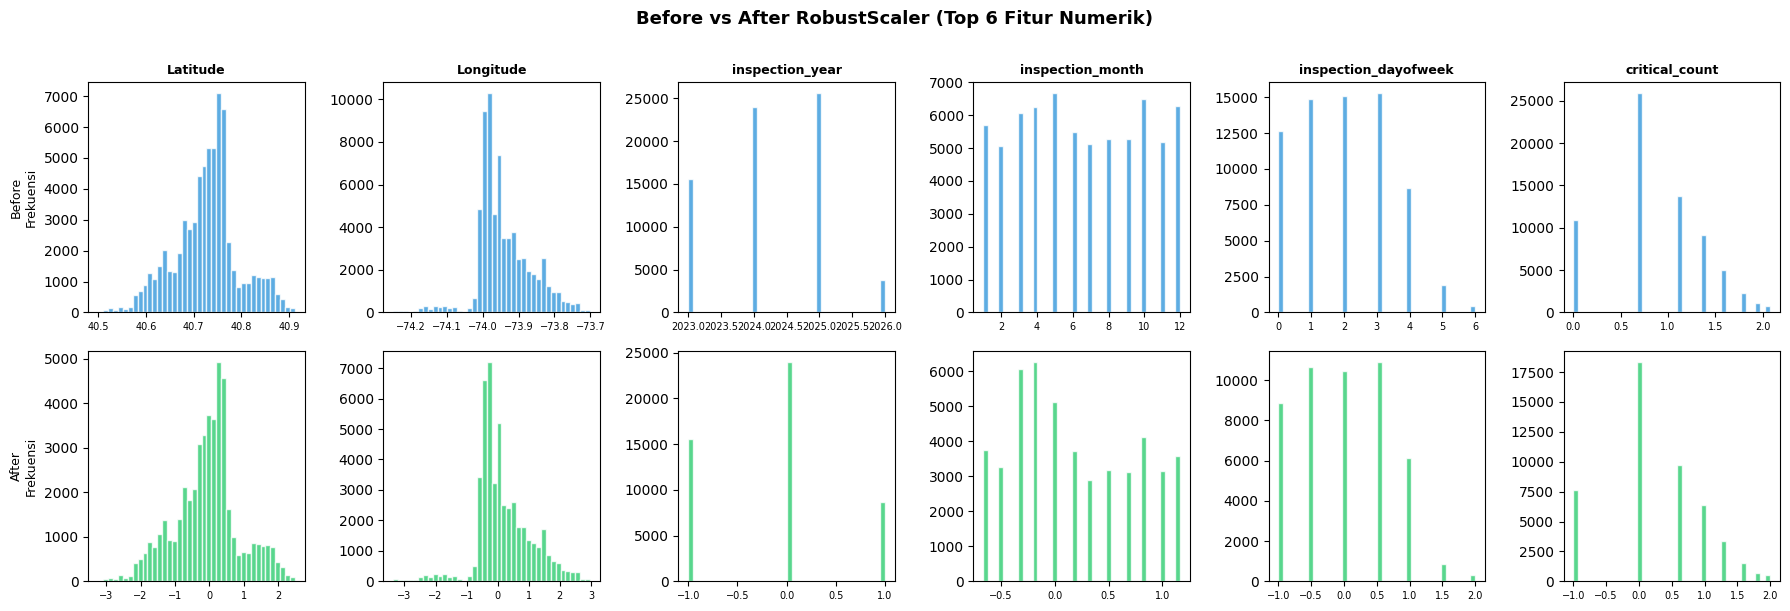

In [ ]:
top6_scale = [c for c in X_train.columns if c in scale_cols][:6]

df_before = df_encoded[top6_scale].copy()

fig, axes = plt.subplots(2, len(top6_scale), figsize=(18, 6))

for i, col in enumerate(top6_scale):
    axes[0, i].hist(df_before[col].dropna(), bins=40,
                    color="#3498db", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(col, fontsize=9, fontweight="bold")
    axes[0, i].tick_params(axis="x", labelsize=7)
    if i == 0: axes[0, i].set_ylabel("Before\nFrekuensi", fontsize=9)

    axes[1, i].hist(X_train[col].dropna(), bins=40,
                    color="#2ecc71", edgecolor="white", alpha=0.8)
    axes[1, i].tick_params(axis="x", labelsize=7)
    if i == 0: axes[1, i].set_ylabel("After\nFrekuensi", fontsize=9)

plt.suptitle("Before vs After RobustScaler (Top 6 Fitur Numerik)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

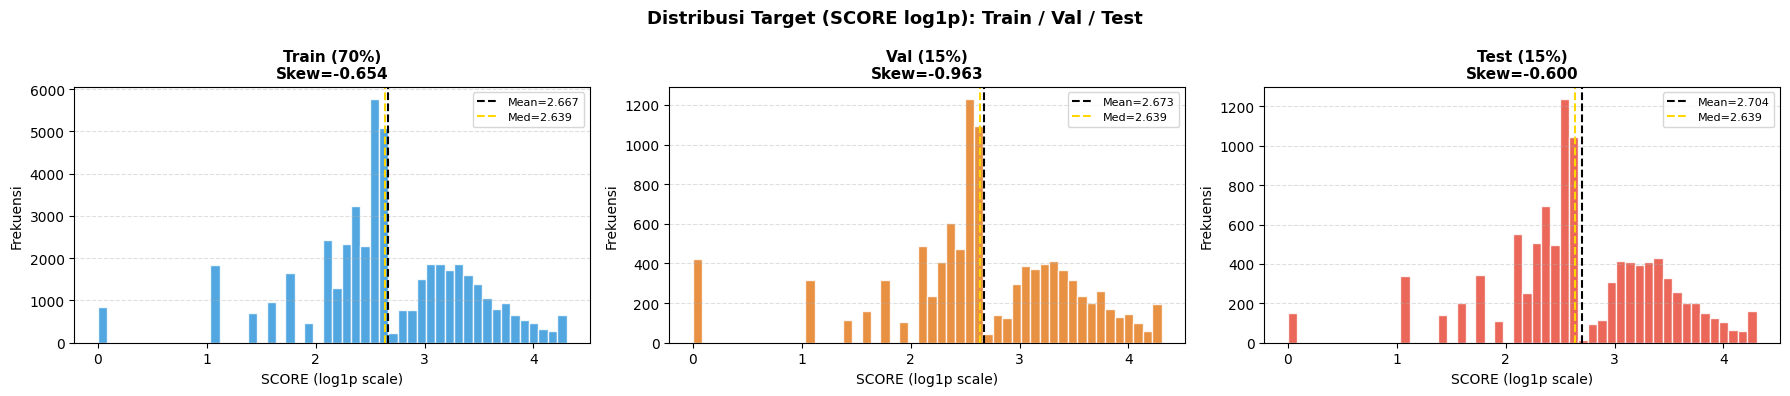

Cek: distribusi ketiga set harus mirip
Train skewness : -0.654
Val   skewness : -0.963
Test  skewness : -0.600


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sets = [
    (y_train, "Train (70%)",  "#3498db"),
    (y_val,   "Val (15%)",    "#e67e22"),
    (y_test,  "Test (15%)",   "#e74c3c"),
]

for ax, (data, label, color) in zip(axes, sets):
    ax.hist(data, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="black", linestyle="--", linewidth=1.5,
               label=f"Mean={data.mean():.3f}")
    ax.axvline(data.median(), color="gold",  linestyle="--", linewidth=1.5,
               label=f"Med={data.median():.3f}")
    ax.set_title(f"{label}\nSkew={data.skew():.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("SCORE (log1p scale)"); ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Distribusi Target (SCORE log1p): Train / Val / Test",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Cek: distribusi ketiga set harus mirip")
print(f"Train skewness : {y_train.skew():.3f}")
print(f"Val   skewness : {y_val.skew():.3f}")
print(f"Test  skewness : {y_test.skew():.3f}")

### Geospatial Density Feature

In [ ]:
from sklearn.neighbors import BallTree

print("Menghitung Geospatial Density Features (radius 1km)...")

df_geo = df_ins[["CAMIS", "Latitude", "Longitude", "SCORE"]].copy()
df_geo["Latitude"]  = pd.to_numeric(df_geo["Latitude"],  errors="coerce")
df_geo["Longitude"] = pd.to_numeric(df_geo["Longitude"], errors="coerce")
df_geo["SCORE"]     = pd.to_numeric(df_geo["SCORE"],     errors="coerce")
df_geo = df_geo.dropna(subset=["Latitude", "Longitude", "SCORE"])
df_geo["CAMIS"] = df_geo["CAMIS"].astype(str)

n_base = len(df_base)
train_end = int(n_base * 0.70)
val_end   = int(n_base * 0.85)

df_dates = df_base[["CAMIS", "INSPECTION DATE"]].copy()
df_dates["INSPECTION DATE"] = pd.to_datetime(df_dates["INSPECTION DATE"])
df_dates = df_dates.sort_values("INSPECTION DATE").reset_index(drop=True)
df_dates["CAMIS"] = df_dates["CAMIS"].astype(str)

camis_train = set(df_dates.iloc[:train_end]["CAMIS"])
camis_val   = set(df_dates.iloc[train_end:val_end]["CAMIS"])
camis_test  = set(df_dates.iloc[val_end:]["CAMIS"])

tr_geo = df_geo[df_geo["CAMIS"].isin(camis_train)].copy()
vl_geo = df_geo[df_geo["CAMIS"].isin(camis_val)].copy()
te_geo = df_geo[df_geo["CAMIS"].isin(camis_test)].copy()

print(f"  Koordinat valid — Train: {len(tr_geo):,} | Val: {len(vl_geo):,} | Test: {len(te_geo):,}")

score_threshold = tr_geo["SCORE"].quantile(0.75)
train_scores    = tr_geo["SCORE"].values

train_coords_rad = np.radians(tr_geo[["Latitude", "Longitude"]].values)
tree = BallTree(train_coords_rad, metric="haversine")

print(f"  Score P75 threshold: {score_threshold:.2f}")
print(f"  BallTree dibangun dari {len(tr_geo):,} titik train")

def query_density(coords_rad, tree, train_scores, threshold, radius_km=1.0):
    r_rad = radius_km / 6371.0
    indices = tree.query_radius(coords_rad, r=r_rad)
    density_high = [(train_scores[idx] > threshold).sum() for idx in indices]
    density_mean = [train_scores[idx].mean() if len(idx) > 0 else np.nan for idx in indices]
    return density_high, density_mean

for geo_df, X_set, set_name in [
    (tr_geo, X_train, "Train"),
    (vl_geo, X_val,   "Val"),
    (te_geo, X_test,  "Test"),
]:
    coords_rad = np.radians(geo_df[["Latitude", "Longitude"]].values)
    d_high, d_mean = query_density(coords_rad, tree, train_scores, score_threshold)

    density_high_s = pd.Series(d_high, index=geo_df.index)
    density_mean_s = pd.Series(d_mean, index=geo_df.index)

    X_set["density_high_1000m"] = density_high_s.reindex(X_set.index)
    X_set["density_mean_1000m"] = density_mean_s.reindex(X_set.index)

fill_high = X_train["density_high_1000m"].median()
fill_mean = X_train["density_mean_1000m"].median()

for X_ in [X_train, X_val, X_test]:
    X_["density_high_1000m"] = X_["density_high_1000m"].fillna(fill_high)
    X_["density_mean_1000m"] = X_["density_mean_1000m"].fillna(fill_mean)

print(f"\n✅ Geospatial density features ditambahkan")
print(f"  density_high_1000m — median={fill_high:.1f}, "
      f"max={X_train['density_high_1000m'].max():.0f}")
print(f"  density_mean_1000m — median={fill_mean:.2f}, "
      f"max={X_train['density_mean_1000m'].max():.2f}")
print(f"\nShape X_train setelah tambah geo density: {X_train.shape}")

Menghitung Geospatial Density Features (radius 1km)...
  Koordinat valid — Train: 64,902 | Val: 25,761 | Test: 25,974
  Score P75 threshold: 24.00
  BallTree dibangun dari 64,902 titik train

✅ Geospatial density features ditambahkan
  density_high_1000m — median=142.0, max=957
  density_mean_1000m — median=17.44, max=28.14

Shape X_train setelah tambah geo density: (48202, 40)


In [ ]:
from scipy import stats

for feat in ["density_high_1000m", "density_mean_1000m"]:
    valid = pd.DataFrame({
        "feat":  X_train[feat],
        "score": y_train
    }).dropna()
    rho, p = stats.spearmanr(valid["feat"], valid["score"])
    print(f"  {feat:<25} ρ={rho:+.4f}  p={p:.4f}")

print()
print(f"Jumlah fitur total setelah Step 10: {X_train.shape[1]}")

  density_high_1000m        ρ=-0.0007  p=0.8830
  density_mean_1000m        ρ=+0.0032  p=0.4820

Jumlah fitur total setelah Step 10: 40
